
EMARS
/scratch/bell/hu1029/Mars-BAM_interm/EMARS_preprocessed_dailyVar/Merged/EMARS_combinedwithGap_merged_daily_global_t_MY24Ls090-MY33Ls120.nc

Dimensions:
Frozen({'time': 5330, 'lon': 60, 'lat': 36, 'level': 60})

Time length:
5330

MY:
24.0 -> 33.0

Ls:
103.72250000000001 -> 104.49875000000002

Unique sol diff:
[  1. 691.]


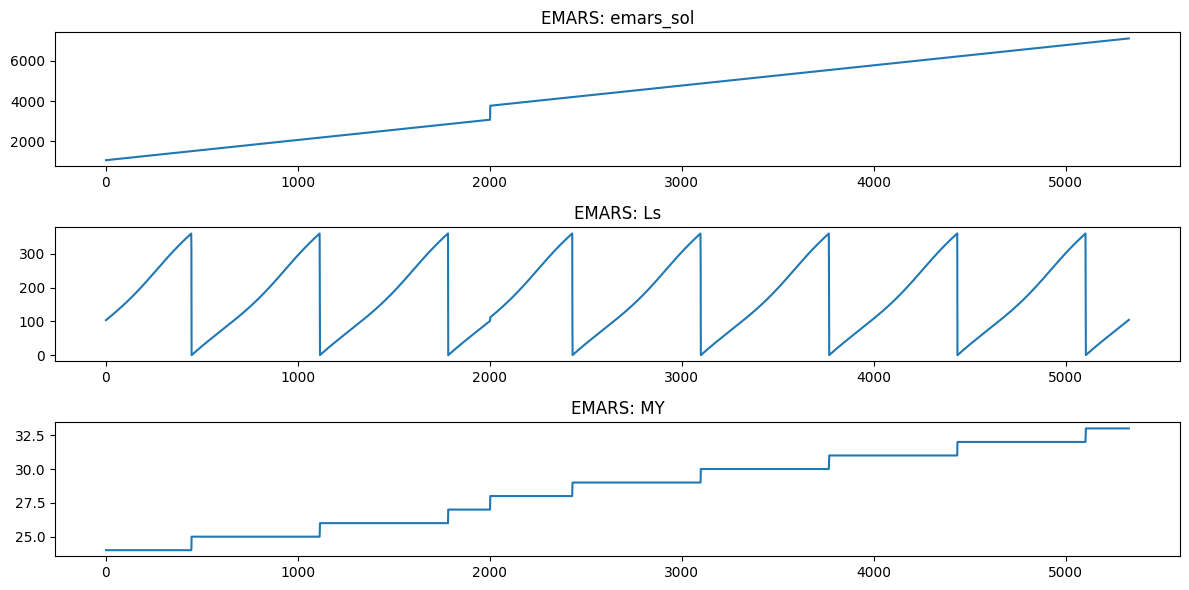


MACDA
/scratch/bell/hu1029/Mars-BAM_interm/MACDA_preprocessed_dailyVar/Merged/MACDA_combinedwithGap_merged_daily_global_t_MY24SOY211-MY31SOY271.nc

Dimensions:
Frozen({'time': 3900, 'lon': 72, 'lat': 36, 'level': 30})

Time length:
3900

MY:
24 -> 31

Ls:
97.85315 -> 125.59909

Unique sol diff:
[  1  31  91 721]


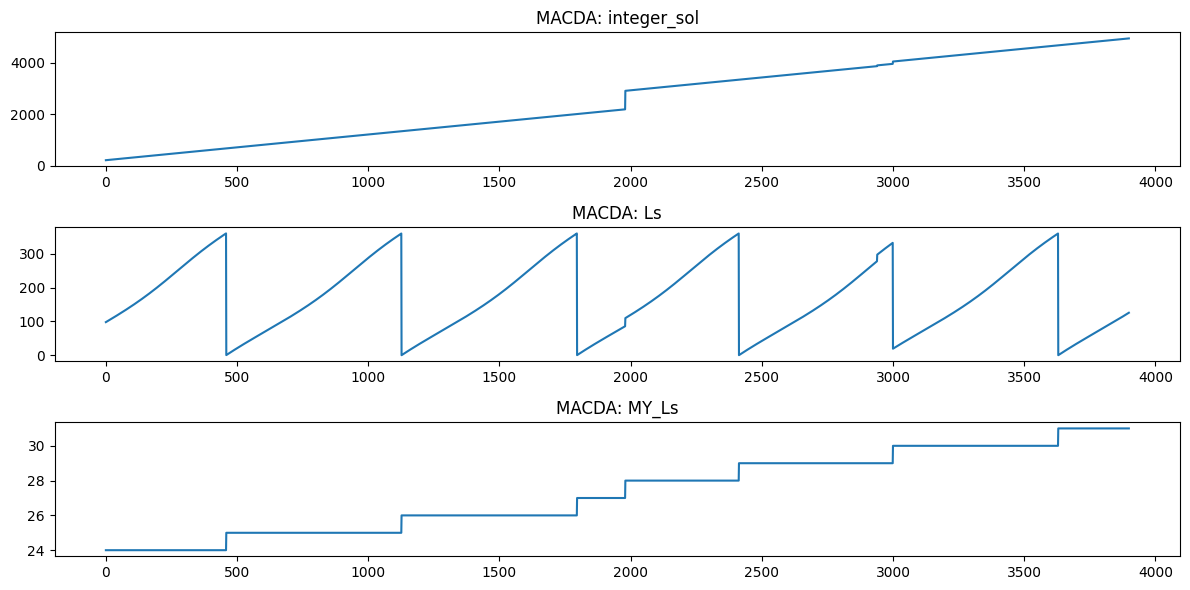


OPENMARS
/scratch/bell/hu1029/Mars-BAM_interm/OpenMars_preprocessed_dailyVar/Merged/OPENMARS_mro-mcs_merged_daily_global_t_MY27Ls358-MY36Ls008.nc

Dimensions:
Frozen({'time': 5370, 'lon': 72, 'lat': 36, 'level': 30})

Time length:
5370

MY:
27 -> 36

Ls:
358.53143 -> 8.767944

Unique sol diff:
[1]


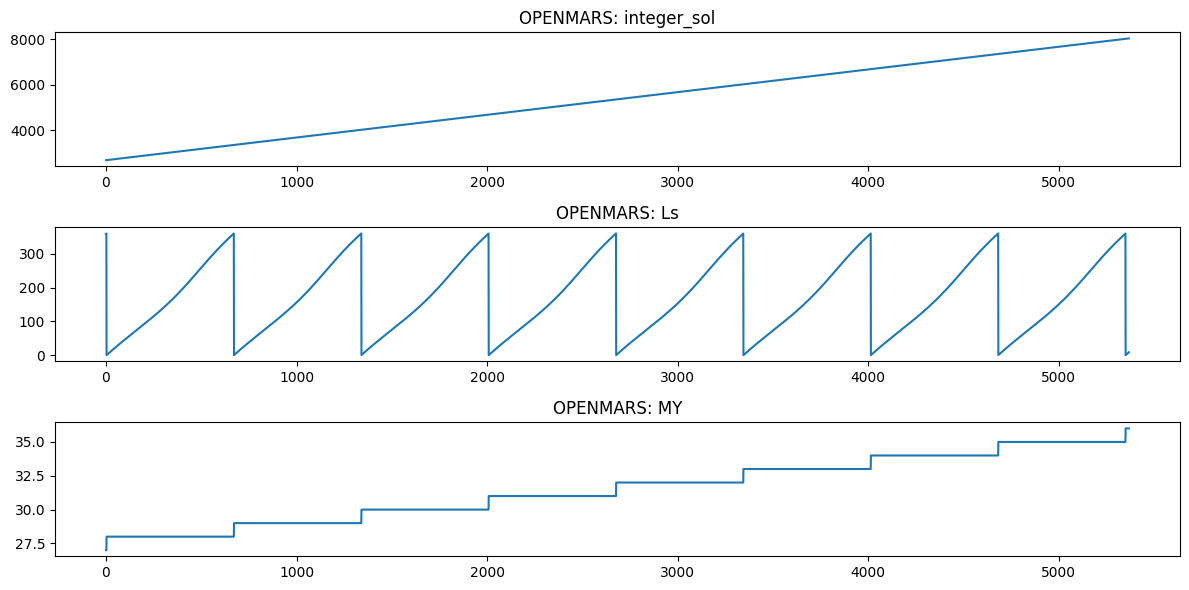

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob

files = {
    "EMARS": glob.glob("/scratch/bell/hu1029/Mars-BAM_interm/EMARS_preprocessed_dailyVar/Merged/EMARS_combinedwithGap_merged_daily_global_t_*.nc")[0],

    "MACDA": glob.glob("/scratch/bell/hu1029/Mars-BAM_interm/MACDA_preprocessed_dailyVar/Merged/MACDA_combinedwithGap_merged_daily_global_t_*.nc")[0],

    "OPENMARS": glob.glob("/scratch/bell/hu1029/Mars-BAM_interm/OpenMars_preprocessed_dailyVar/Merged/OPENMARS_mro-mcs_merged_daily_global_t_*.nc")[0],
}

solnameList = {"EMARS": 'emars_sol', 'MACDA': 'integer_sol', 'OPENMARS': 'integer_sol'}
MYnameList = {"EMARS": 'MY', 'MACDA': 'MY_Ls', 'OPENMARS': 'MY'}

for name, file in files.items():

    print("\n" + "="*80)
    print(name)
    print(file)

    ds = xr.open_dataset(file)

    print("\nDimensions:")
    print(ds.sizes)

    print("\nTime length:")
    print(ds.sizes["time"])

    print("\nMY:")
    MYname = MYnameList[name]
    print(ds[MYname].values[0], "->", ds[MYname].values[-1])

    print("\nLs:")
    print(ds.Ls.values[0], "->", ds.Ls.values[-1])

    solname = solnameList[name]
    print("\nUnique sol diff:")
    print(np.unique(np.diff(ds[solname].values)))

    fig, axs = plt.subplots(3, 1, figsize=(12, 6))

    axs[0].plot(ds[solname])
    axs[0].set_title(f"{name}: {solname}")

    axs[1].plot(ds.Ls)
    axs[1].set_title(f"{name}: Ls")

    axs[2].plot(ds[MYname])
    axs[2].set_title(f"{name}: {MYname}")

    plt.tight_layout()
    plt.show()

    ds.close()

In [14]:
name = 'MACDA'
file = files[name]
MYname = MYnameList[name]
ds = xr.open_dataset(file)

dsol = np.diff(ds.integer_sol.values)

idx = np.where(dsol > 1)[0]

for i in idx:
    print(
        i,
        'MY',ds[MYname].values[i],
        'Ls',ds.Ls.values[i],
        'SOL',ds.integer_sol.values[i],
        " -jump-> ",
        'MY',ds[MYname].values[i+1],
        'Ls',ds.Ls.values[i+1],
        'SOL',ds.integer_sol.values[i+1],
        " diff in Sol=",
        dsol[i]
    )

1979 MY 27 Ls 85.666504 SOL 2189  -jump->  MY 28 Ls 109.72058 SOL 2910  diff in Sol= 721
2939 MY 29 Ls 277.73874 SOL 3869  -jump->  MY 29 Ls 297.2633 SOL 3900  diff in Sol= 31
2999 MY 29 Ls 332.09036 SOL 3959  -jump->  MY 30 Ls 19.377258 SOL 4050  diff in Sol= 91


In [27]:
# Check MY29

from pathlib import Path
import re
import numpy as np
import xarray as xr

data_dir = Path("/depot/wanglei/data/MACDA_v2")

files = sorted(
    list(data_dir.glob("mro-mcs-reanalysis_mars_MY29SOY*_MY29SOY*_v2-0.nc"))
    + list(data_dir.glob("mro-mcs-reanalysis_mars_MY30SOY040_MY30SOY070_v2-0.nc"))
)
print(f"Found {len(files)} files\n")

# ------------------------------------------------------------------
# 1. check if the data files are continuous
# ------------------------------------------------------------------
import re

starts = []
ends = []

for f in files:

    m = re.search(
        r"MY(\d+)SOY(\d+)_MY(\d+)SOY(\d+)",
        f.name
    )

    start_my = int(m.group(1))
    start_soy = int(m.group(2))

    end_my = int(m.group(3))
    end_soy = int(m.group(4))

    # convert to continuous sol index
    start = start_my * 669 + start_soy
    end = end_my * 669 + end_soy

    starts.append(start)
    ends.append(end)

print("\nFile continuity check:")

for i in range(len(files)-1):

    gap = starts[i+1] - ends[i]

    if gap != 0:
        print(
            f"Gap after {files[i].name}: "
            f"{ends[i]} -> {starts[i+1]} "
            f"(diff={gap})"
        )


Found 20 files


File continuity check:
Gap after mro-mcs-reanalysis_mars_MY29SOY498_MY29SOY528_v2-0.nc: 19929 -> 19959 (diff=30)
Gap after mro-mcs-reanalysis_mars_MY29SOY588_MY29SOY618_v2-0.nc: 20019 -> 20110 (diff=91)
